<a href="https://colab.research.google.com/github/NeevWadhwa-Helloworld/Machine-Learning-Projects/blob/main/Spam_SMS_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **SMS spam detection model**

In [1]:
import numpy as np
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df_sms=pd.read_csv('/content/Requirments (2).zip',encoding='latin-1')
df_sms.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df_sms=df_sms.rename(columns={"v1":"labels","v2":"sms"})
df_sms.head()

,labels,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print(len(df_sms))

5572


In [9]:
df_sms.describe()

,labels,sms
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [10]:
df_sms['length']=df_sms['sms'].apply(len)
df_sms.head()

,labels,sms,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


<Axes: ylabel='Frequency'>

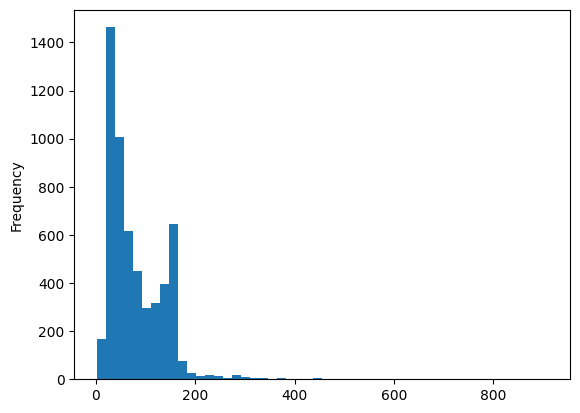

In [37]:
df_sms['length'].plot(bins=50,kind='hist')

In [43]:
documents=['Hello , how are you!','Win money , win from home.','Call me now.','Hello,Call hello you tomorrow?']
lower_case_documents=[]
lower_case_documents=[d.lower() for d in documents]
print(lower_case_documents)

['hello , how are you!', 'win money , win from home.', 'call me now.', 'hello,call hello you tomorrow?']


In [44]:
sans_punctuation_documents=[]
import string
for i in lower_case_documents:
  sans_punctuation_documents.append(i.translate(str.maketrans('','',string.punctuation)))
print(sans_punctuation_documents)

['hello  how are you', 'win money  win from home', 'call me now', 'hellocall hello you tomorrow']


In [45]:
preprocessed_documents=[[w for w in d.split()] for d in sans_punctuation_documents]
preprocessed_documents

[['hello', 'how', 'are', 'you'],
 ['win', 'money', 'win', 'from', 'home'],
 ['call', 'me', 'now'],
 ['hellocall', 'hello', 'you', 'tomorrow']]

In [46]:
frequency_list=[]
import pprint
from collections import Counter

frequency_list=[Counter(d) for d in preprocessed_documents]
pprint.pprint(frequency_list)

[Counter({'hello': 1, 'how': 1, 'are': 1, 'you': 1}),
 Counter({'win': 2, 'money': 1, 'from': 1, 'home': 1}),
 Counter({'call': 1, 'me': 1, 'now': 1}),
 Counter({'hellocall': 1, 'hello': 1, 'you': 1, 'tomorrow': 1})]


In [47]:
from sklearn.feature_extraction.text import CountVectorizer
count_vector=CountVectorizer()

# **PreProcessing with CountVectorizer**

In [48]:
count_vector.fit(documents)
count_vector.get_feature_names_out()

array(['are', 'call', 'from', 'hello', 'home', 'how', 'me', 'money',
       'now', 'tomorrow', 'win', 'you'], dtype=object)

In [49]:
doc_array=count_vector.transform(documents).toarray()
doc_array

array([[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 2, 0],
       [0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
       [0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1]])

In [50]:
frequency_matrix=pd.DataFrame(doc_array,columns=count_vector.get_feature_names_out())
frequency_matrix

,are,call,from,hello,home,how,me,money,now,tomorrow,win,you
0,1,0,0,1,0,1,0,0,0,0,0,1
1,0,0,1,0,1,0,0,1,0,0,2,0
2,0,1,0,0,0,0,1,0,1,0,0,0
3,0,1,0,2,0,0,0,0,0,1,0,1


In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df_sms['sms'],df_sms['labels'],test_size=0.2,random_state=1)

In [52]:
count_vector=CountVectorizer()
training_data=count_vector.fit_transform(X_train)
testing_data=count_vector.transform(X_test)


## **Navie Bayes Machine Learning Algo**

In [53]:
from sklearn.naive_bayes import MultinomialNB
naive_bayes=MultinomialNB()
naive_bayes.fit(training_data,y_train)

ValueError: Input contains NaN

In [55]:
MultinomialNB(alpha=1.0,class_prior=None,fit_prior=True)

MultinomialNB()

In [56]:
precictions=native_bayes.predict(testing_data)

NameError: name 'native_bayes' is not defined

In [58]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print('Accuracy score: ',format(accuracy_score(y_test,precictions)))
print('Precision score: ',format(precision_score(y_test,precictions)))
print('Recall score: ',format(recall_score(y_test,precictions)))
print('F1 score: ',format(f1_score(y_test,precictions)))

NameError: name 'precictions' is not defined